# Diabetes Prediction — MLP Neural Network + XAI

| | |
|---|---|
| **Student** | Abdallah Saed — 202201933 |
| **Dataset** | BRFSS 2015 Diabetes Health Indicators |
| **Model** | MLP (Dense Neural Network) — 3 hidden layers (128-64-32) |
| **XAI** | SHAP (DeepExplainer) · LIME · Permutation Importance · PDP + ICE |

## 1. Install and Import Libraries

In [ ]:
!pip install tensorflow shap lime scikit-learn imbalanced-learn pandas numpy matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, average_precision_score, fbeta_score,
    precision_recall_curve
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import shap
import lime
import lime.lime_tabular

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='Set2')
print("All libraries imported.")

All libraries imported.


## 2. Load Dataset

In [ ]:
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

print(f"Shape         : {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates    : {df.duplicated().sum()}")
df.head()

Shape         : (253680, 22)
Missing values: 0
Duplicates    : 24206


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. Exploratory Data Analysis

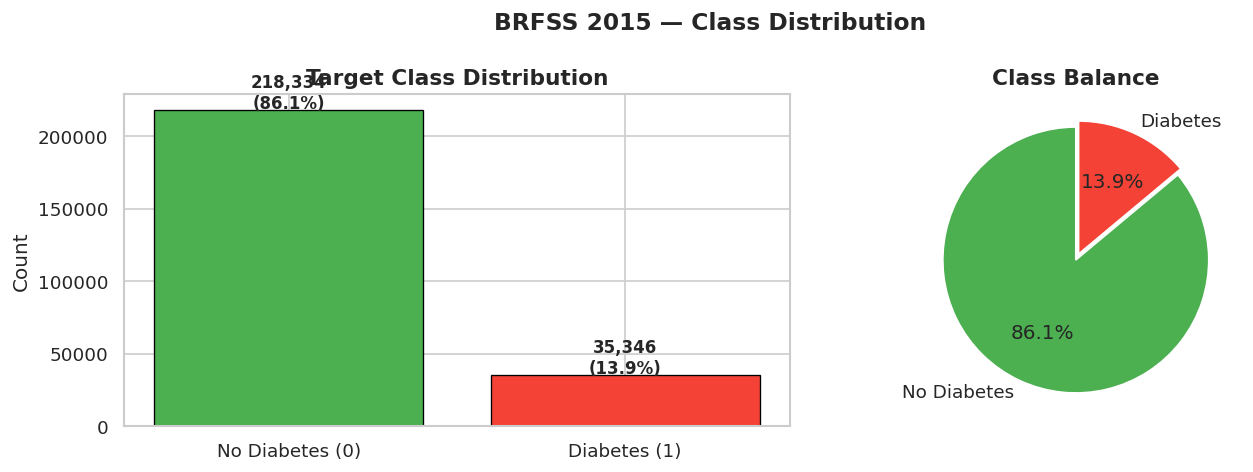

In [ ]:
counts = df['Diabetes_binary'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].pie(counts.values, labels=['No Diabetes', 'Diabetes'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('BRFSS 2015 — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_01_class_distribution.png', bbox_inches='tight')
plt.show()

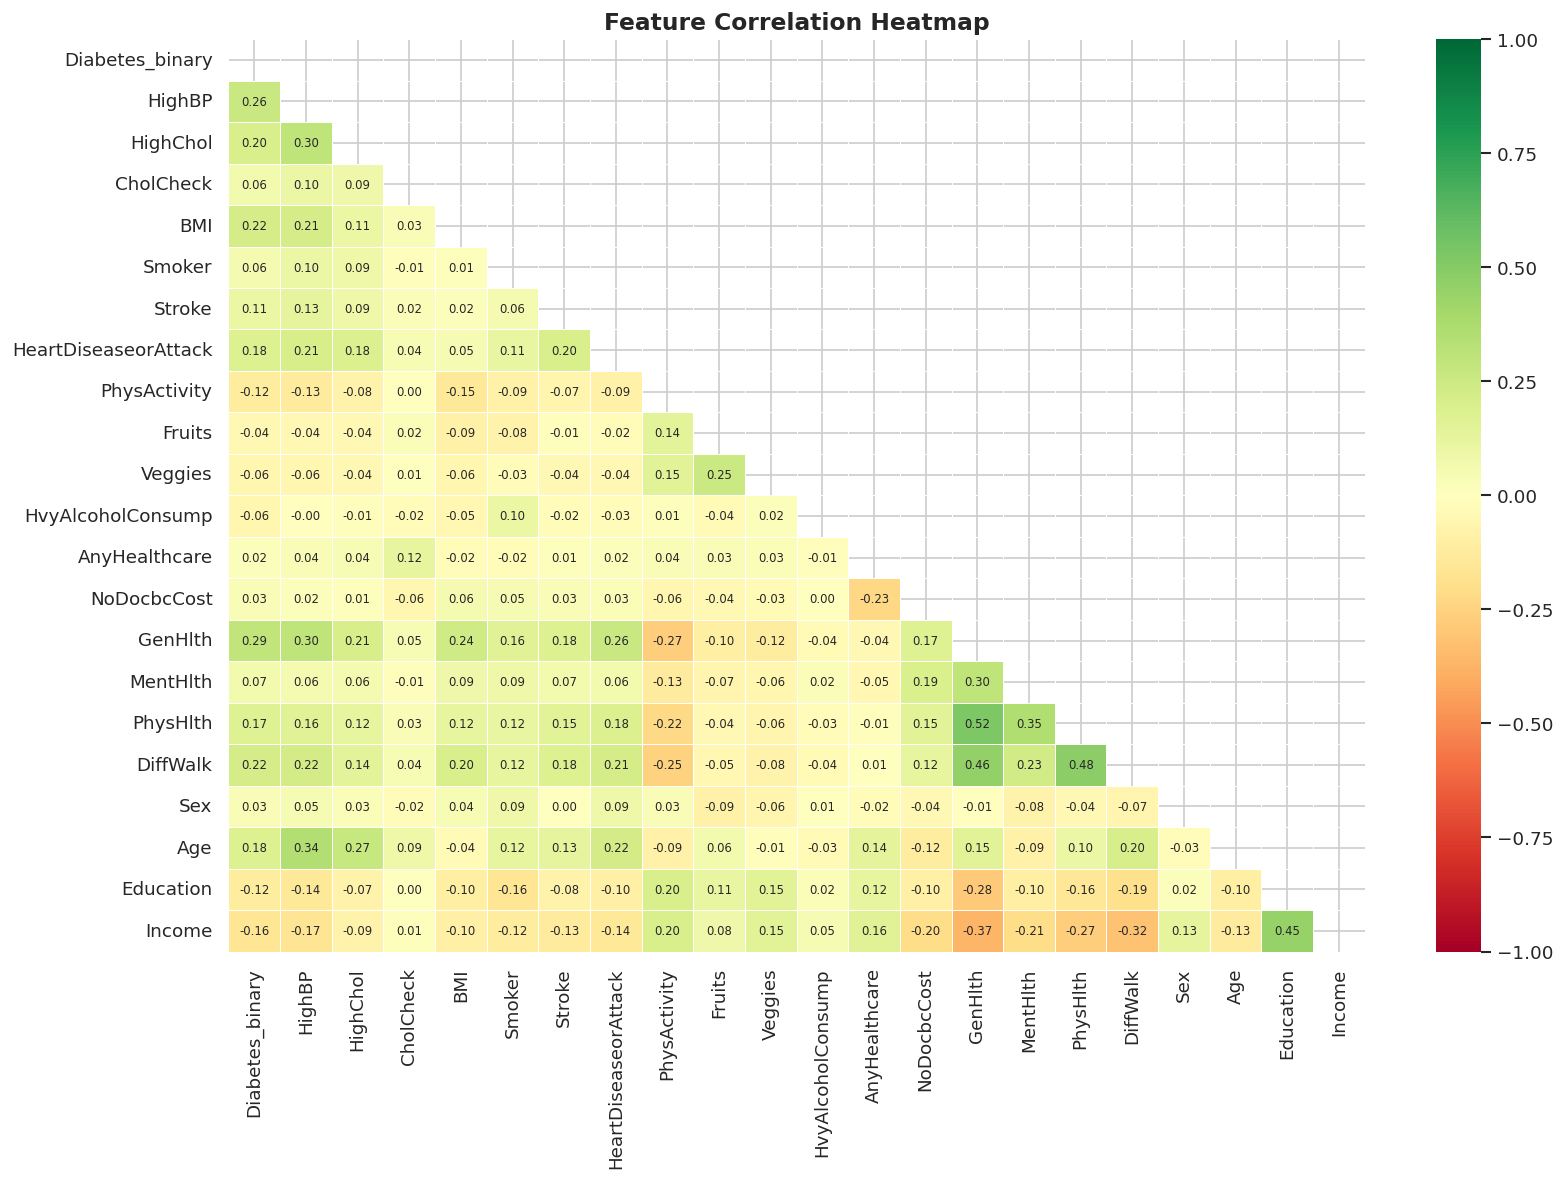

In [ ]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.4, annot_kws={'size': 7}, center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_02_correlation_heatmap.png', bbox_inches='tight')
plt.show()


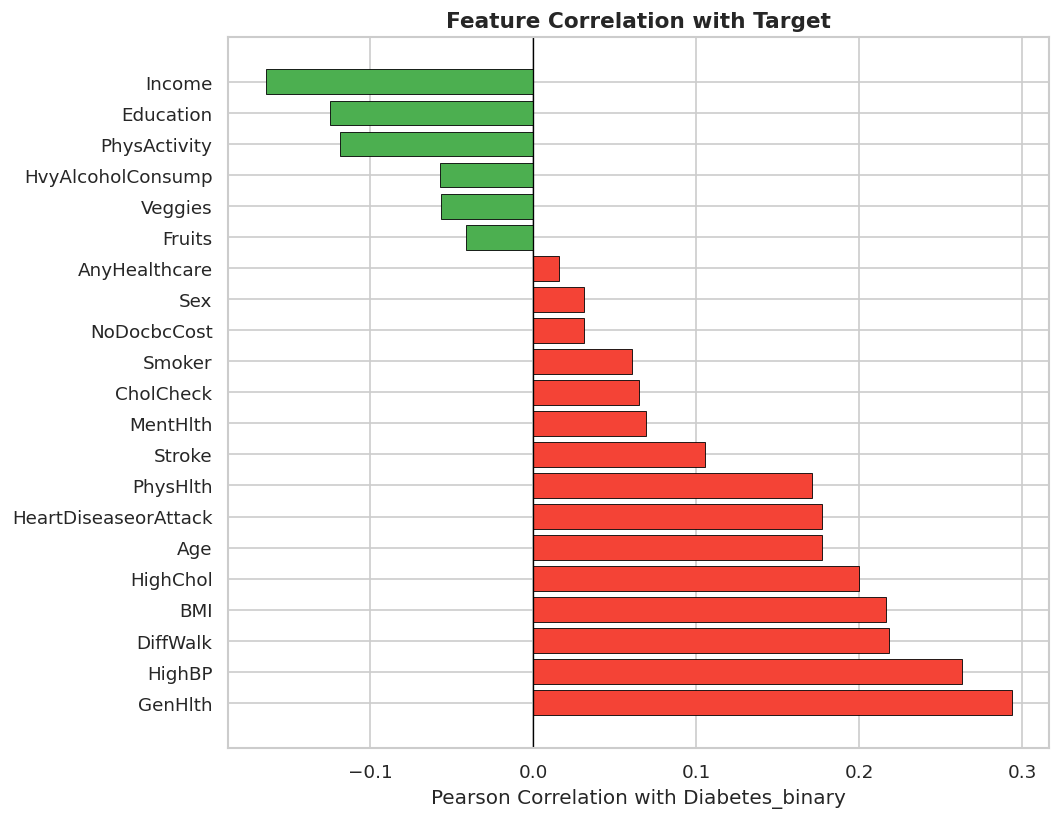

In [ ]:
target_corr = df.corr(numeric_only=True)['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)
colors = ['#F44336' if v > 0 else '#4CAF50' for v in target_corr.values]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Diabetes_binary', fontsize=12)
ax.set_title('Feature Correlation with Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_03_target_correlation.png', bbox_inches='tight')
plt.show()


## 4. Preprocessing

Pipeline:
1. Remove duplicates
2. IQR outlier clipping on continuous features
3. Select top 10 features
4. 80/20 stratified train/test split
5. Mean imputation then StandardScaler (fit on train only)
6. SMOTE on training set only

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

# IQR outlier clipping on continuous columns
continuous_features = [col for col in df.columns if df[col].nunique() > 15]
for col in continuous_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

FEATURES = [
    'GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol',
    'Age', 'HeartDiseaseorAttack', 'PhysHlth', 'MentHlth', 'Income'
]
TARGET = 'Diabetes_binary'

X = df[FEATURES].values
y = df[TARGET].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Train (after SMOTE): {X_train_res.shape}  |  Test: {X_test_scaled.shape}")
print(f"Class 0: {sum(y_train_res==0):,}  |  Class 1: {sum(y_train_res==1):,}")

Train (after SMOTE): (311002, 10)  |  Test: (45895, 10)
Class 0: 155,501  |  Class 1: 155,501


---
## 5. MLP Neural Network Model

Architecture: Input(10) -> Dense(128, ReLU) -> BN -> Dropout(0.3) -> Dense(64, ReLU) -> BN -> Dropout(0.3) -> Dense(32, ReLU) -> Dropout(0.2) -> Dense(1, Sigmoid)

In [ ]:
def build_mlp(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

mlp_model = build_mlp(X_train_res.shape[1])
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
]

history = mlp_model.fit(
    X_train_res, y_train_res,
    epochs=80,
    batch_size=256,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)
print(f"Stopped at epoch: {len(history.history['loss'])}")

Epoch 1/80
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.7215 - auc: 0.7908 - loss: 0.5441 - val_accuracy: 0.7270 - val_auc: 0.0000e+00 - val_loss: 0.6257 - learning_rate: 0.0010
Epoch 2/80
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7350 - auc: 0.8070 - loss: 0.5231 - val_accuracy: 0.7214 - val_auc: 0.0000e+00 - val_loss: 0.6166 - learning_rate: 0.0010
Epoch 3/80
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7364 - auc: 0.8091 - loss: 0.5206 - val_accuracy: 0.7160 - val_auc: 0.0000e+00 - val_loss: 0.6137 - learning_rate: 0.0010
Epoch 4/80
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7371 - auc: 0.8104 - loss: 0.5192 - val_accuracy: 0.7148 - val_auc: 0.0000e+00 - val_loss: 0.6076 - learning_rate: 0.0010
Epoch 5/80
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7381 - auc: 0.8112 - loss: 0.5181 - val_accuracy: 0.7099 - val_auc: 0.0000e+00 - val_loss: 0.6039 - learning_rate: 0.0010
Epoch 6/80
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/

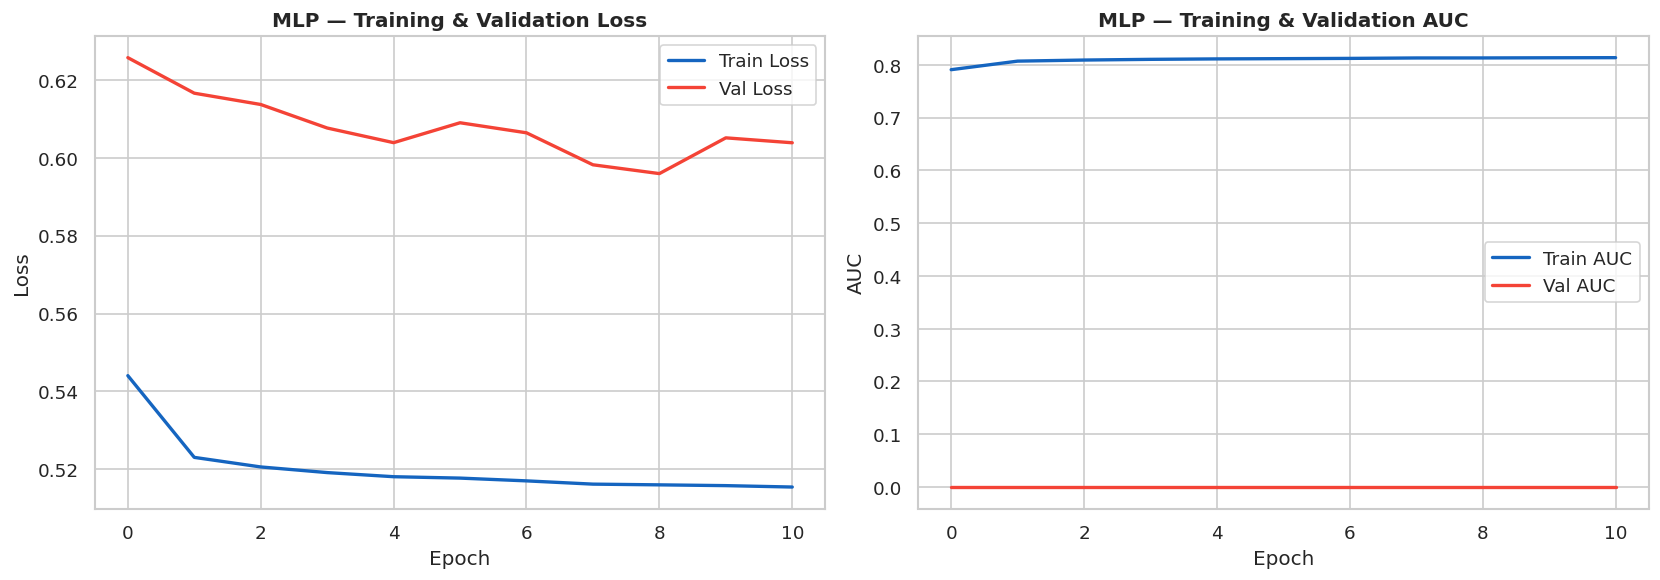

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     color='#1565C0', lw=2, label='Train Loss')
axes[0].plot(history.history['val_loss'], color='#F44336', lw=2, label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('MLP — Training & Validation Loss', fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].plot(history.history['auc'],     color='#1565C0', lw=2, label='Train AUC')
axes[1].plot(history.history['val_auc'], color='#F44336', lw=2, label='Val AUC')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].set_title('MLP — Training & Validation AUC', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('mlp_04_training_curves.png', bbox_inches='tight')
plt.show()

### 5.1 Threshold Tuning (F-beta, beta=1.5)

In [ ]:
mlp_prob = mlp_model.predict(X_test_scaled).flatten()

beta = 1.5
prec_m, rec_m, thr_m = precision_recall_curve(y_test, mlp_prob)
fb_m = (1 + beta**2) * (prec_m * rec_m) / ((beta**2 * prec_m) + rec_m + 1e-9)
best_idx_m = fb_m.argmax()
MLP_THRESHOLD = thr_m[best_idx_m]
print(f"MLP optimal threshold: {MLP_THRESHOLD:.4f}")

1435/1435 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
MLP optimal threshold: 0.4869


### 5.2 Evaluation

In [ ]:
mlp_pred = (mlp_prob >= MLP_THRESHOLD).astype(int)

mlp_acc  = accuracy_score(y_test, mlp_pred)
mlp_prec = precision_score(y_test, mlp_pred)
mlp_rec  = recall_score(y_test, mlp_pred)
mlp_f1   = f1_score(y_test, mlp_pred)
mlp_f2   = fbeta_score(y_test, mlp_pred, beta=2)
mlp_auc  = roc_auc_score(y_test, mlp_prob)
mlp_ap   = average_precision_score(y_test, mlp_prob)

print("=" * 48)
print("  MLP — EVALUATION RESULTS")
print("=" * 48)
print(f"  Threshold  : {MLP_THRESHOLD:.4f}")
print(f"  Accuracy   : {mlp_acc:.4f}")
print(f"  Precision  : {mlp_prec:.4f}")
print(f"  Recall     : {mlp_rec:.4f}")
print(f"  F1         : {mlp_f1:.4f}")
print(f"  F2         : {mlp_f2:.4f}")
print(f"  AUC-ROC    : {mlp_auc:.4f}")
print(f"  Avg Prec   : {mlp_ap:.4f}")
print("=" * 48)
print(classification_report(y_test, mlp_pred, target_names=['No Diabetes', 'Diabetes']))

  MLP — EVALUATION RESULTS
  Threshold  : 0.4869
  Accuracy   : 0.7316
  Precision  : 0.3312
  Recall     : 0.7408
  F1         : 0.4578
  F2         : 0.5939
  AUC-ROC    : 0.8131
  Avg Prec   : 0.4325
              precision    recall  f1-score   support

 No Diabetes       0.94      0.73      0.82     38876
    Diabetes       0.33      0.74      0.46      7019

    accuracy                           0.73     45895
   macro avg       0.64      0.74      0.64     45895
weighted avg       0.85      0.73      0.77     45895



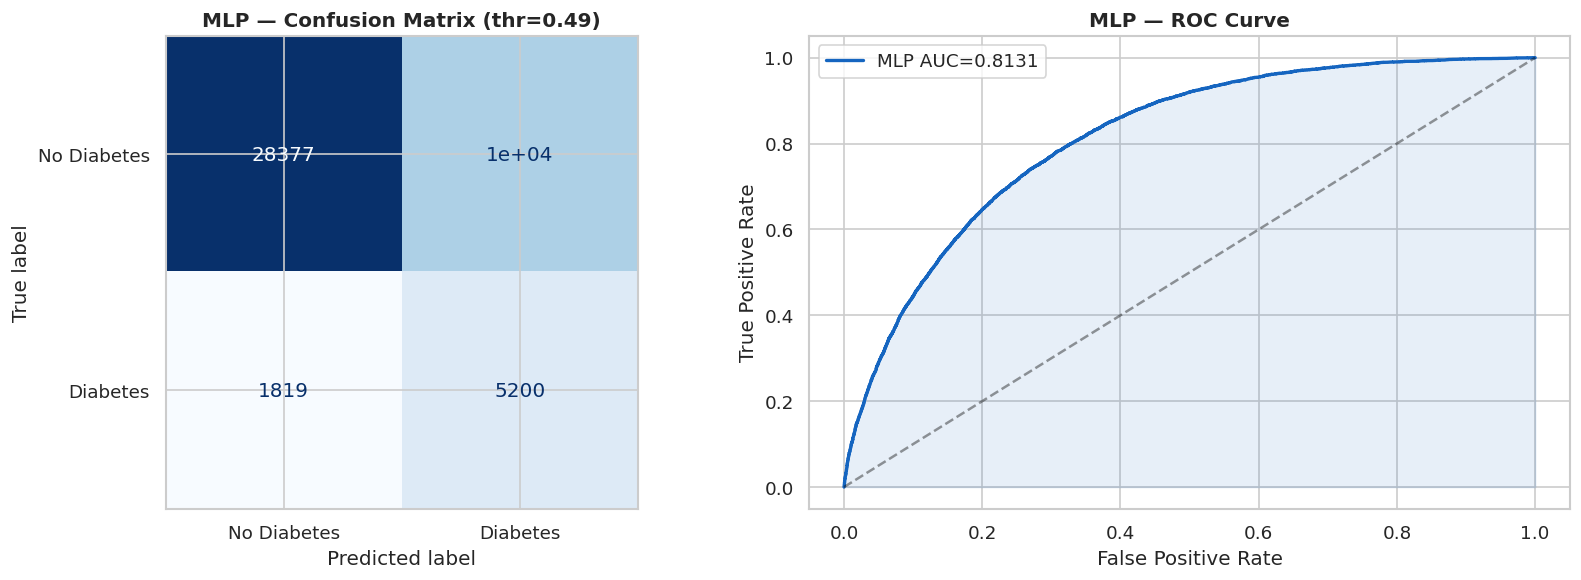

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, mlp_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'MLP — Confusion Matrix (thr={MLP_THRESHOLD:.2f})',
                  fontsize=12, fontweight='bold')

fpr_m, tpr_m, _ = roc_curve(y_test, mlp_prob)
axes[1].plot(fpr_m, tpr_m, color='#1565C0', lw=2, label=f'MLP AUC={mlp_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].fill_between(fpr_m, tpr_m, alpha=0.1, color='#1565C0')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('MLP — ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('mlp_05_evaluation.png', bbox_inches='tight')
plt.show()

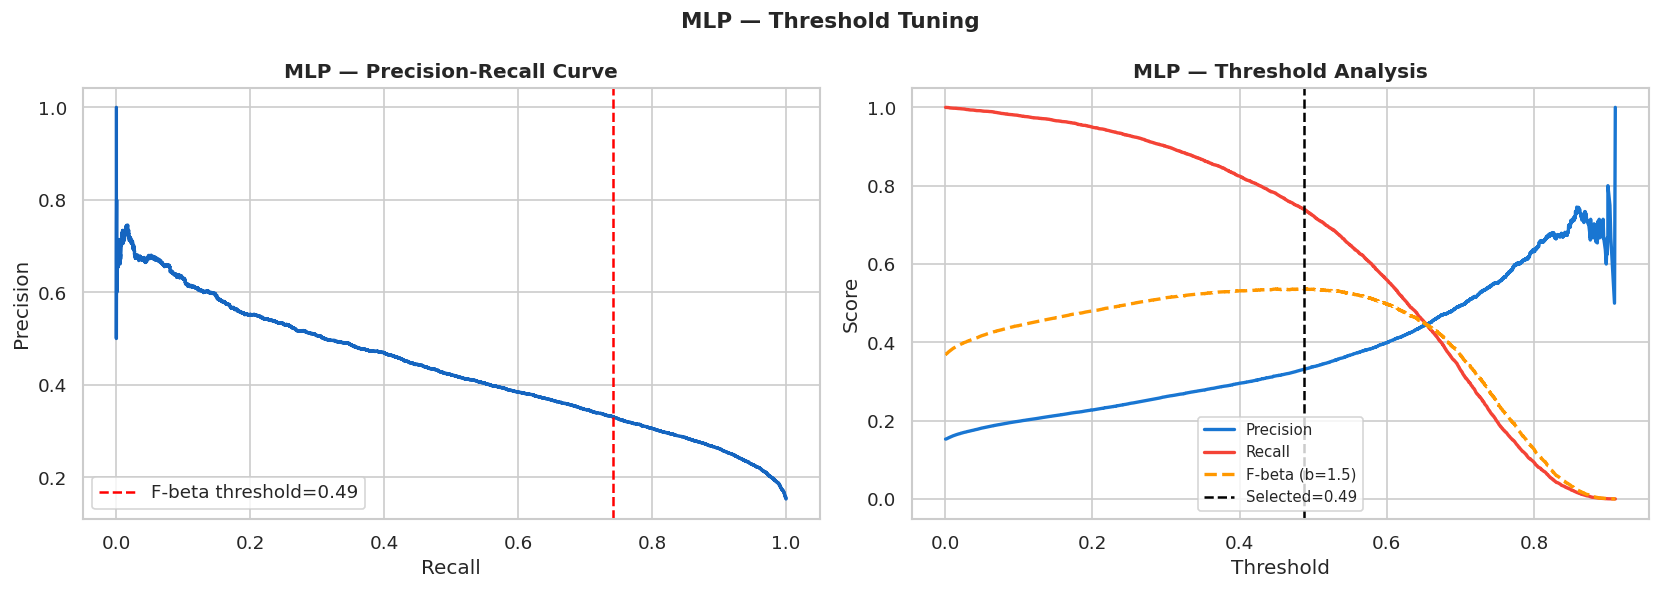

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_m[:-1], prec_m[:-1], color='#1565C0', lw=2)
axes[0].axvline(rec_m[best_idx_m], color='red', linestyle='--', lw=1.5,
                label=f'F-beta threshold={MLP_THRESHOLD:.2f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('MLP — Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].plot(thr_m, prec_m[:-1], color='#1976D2', lw=2, label='Precision')
axes[1].plot(thr_m, rec_m[:-1],  color='#F44336', lw=2, label='Recall')
axes[1].plot(thr_m, fb_m[:-1],   color='#FF9800', lw=2, linestyle='--',
             label=f'F-beta (b={beta})')
axes[1].axvline(MLP_THRESHOLD, color='black', linestyle='--', lw=1.5,
                label=f'Selected={MLP_THRESHOLD:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('MLP — Threshold Analysis', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
plt.suptitle('MLP — Threshold Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_06_threshold.png', bbox_inches='tight')
plt.show()

---
## 6. XAI — MLP Neural Network

Four explainability techniques are applied:
1. SHAP (DeepExplainer) — global summary, waterfall, dependence
2. LIME — local instance explanations
3. Permutation Feature Importance
4. Partial Dependence Plots (PDP) + Individual Conditional Expectation (ICE)

### 6.1 SHAP — DeepExplainer

In [ ]:
print("Computing SHAP values for MLP (DeepExplainer)...")

bg_idx = np.random.choice(len(X_train_res), size=200, replace=False)
X_background = X_train_res[bg_idx]

shap_n = 500
shap_idx = np.random.choice(len(X_test_scaled), size=shap_n, replace=False)
X_shap_mlp = X_test_scaled[shap_idx]

explainer_mlp = shap.DeepExplainer(mlp_model, X_background)
shap_vals_raw = explainer_mlp.shap_values(X_shap_mlp)

if isinstance(shap_vals_raw, list):
    sv_mlp = np.array(shap_vals_raw[0]).squeeze()
else:
    sv_mlp = np.array(shap_vals_raw).squeeze()

if sv_mlp.ndim == 1:
    sv_mlp = sv_mlp.reshape(1, -1)

print(f"SHAP values shape: {sv_mlp.shape}")


Computing SHAP values for MLP (DeepExplainer)...
SHAP values shape: (500, 10)


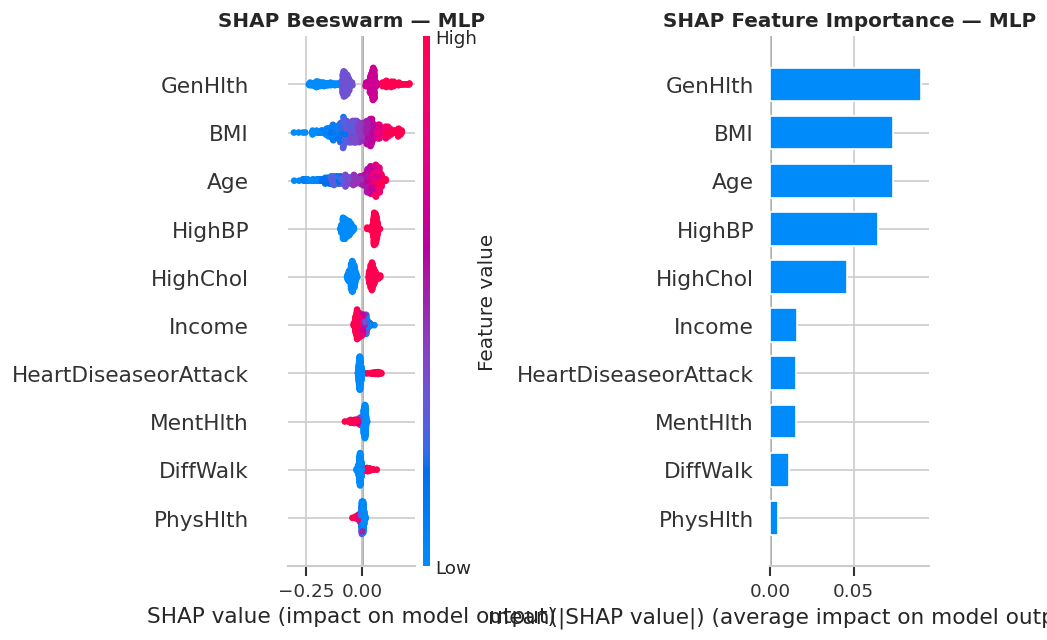

In [ ]:
# SHAP Beeswarm + Bar (global importance)
X_shap_df = pd.DataFrame(X_shap_mlp, columns=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(sv_mlp, X_shap_df, feature_names=FEATURES,
                  plot_type='dot', show=False, max_display=10)
axes[0].set_title('SHAP Beeswarm — MLP', fontsize=12, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(sv_mlp, X_shap_df, feature_names=FEATURES,
                  plot_type='bar', show=False, max_display=10)
axes[1].set_title('SHAP Feature Importance — MLP', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('mlp_07_shap_global.png', bbox_inches='tight')
plt.show()

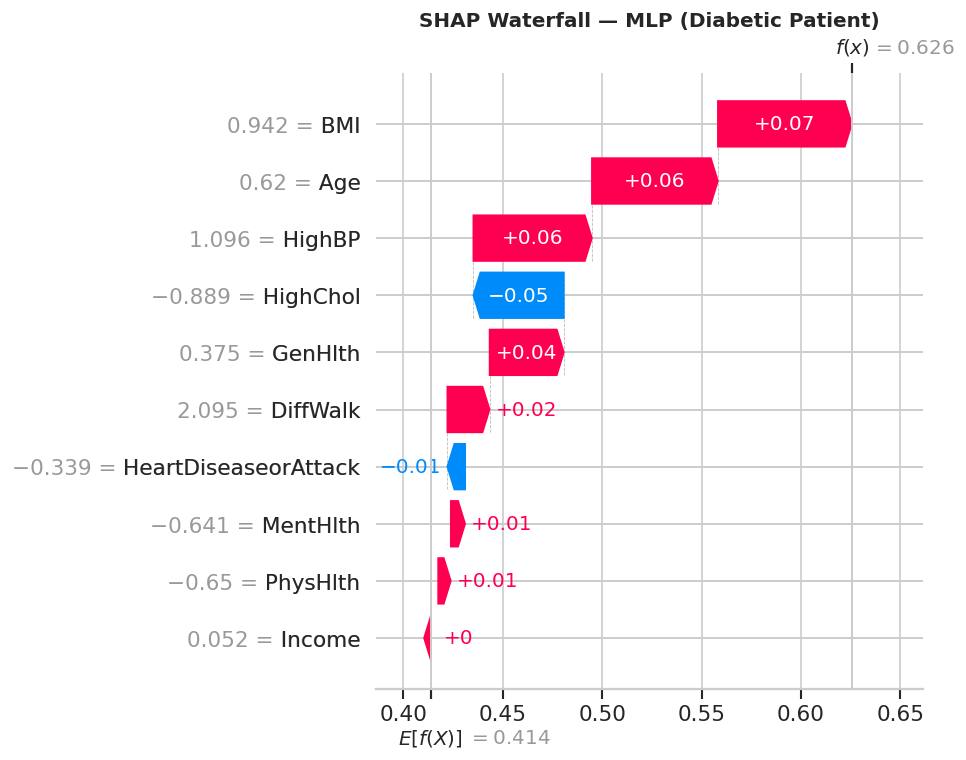

In [ ]:
import tensorflow as tf

exp_val_raw = explainer_mlp.expected_value
if isinstance(exp_val_raw, (list, np.ndarray)):
    exp_val_mlp = float(np.array(exp_val_raw).flatten()[0])
elif tf.is_tensor(exp_val_raw):
    exp_val_mlp = float(exp_val_raw.numpy().flatten()[0])
else:
    exp_val_mlp = float(exp_val_raw)

pos_in_shap = np.where(y_test[shap_idx] == 1)[0][0]

X_shap_df = pd.DataFrame(X_shap_mlp, columns=FEATURES)

shap.waterfall_plot(shap.Explanation(
    values=sv_mlp[pos_in_shap],
    base_values=exp_val_mlp,
    data=X_shap_df.iloc[pos_in_shap].values,
    feature_names=FEATURES
), show=False)
plt.title('SHAP Waterfall — MLP (Diabetic Patient)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_08_shap_waterfall.png', bbox_inches='tight')
plt.show()


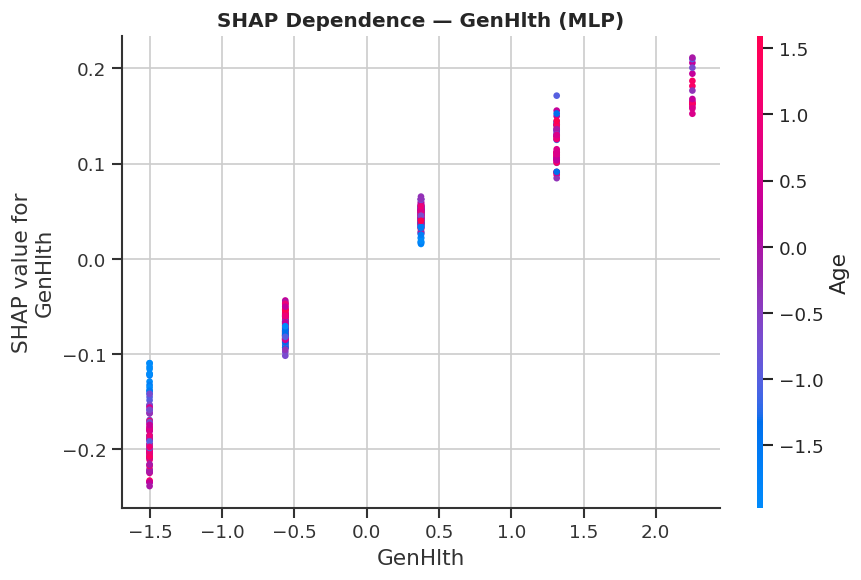

In [ ]:
top_feat_mlp = pd.Series(np.abs(sv_mlp).mean(axis=0), index=FEATURES).idxmax()
shap.dependence_plot(top_feat_mlp, sv_mlp, X_shap_df, show=False)
plt.title(f'SHAP Dependence — {top_feat_mlp} (MLP)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_09_shap_dependence.png', bbox_inches='tight')
plt.show()


### 6.2 LIME — Local Interpretable Model-Agnostic Explanations

LIME MLP  P(No Diabetes)=0.249  P(Diabetes)=0.751


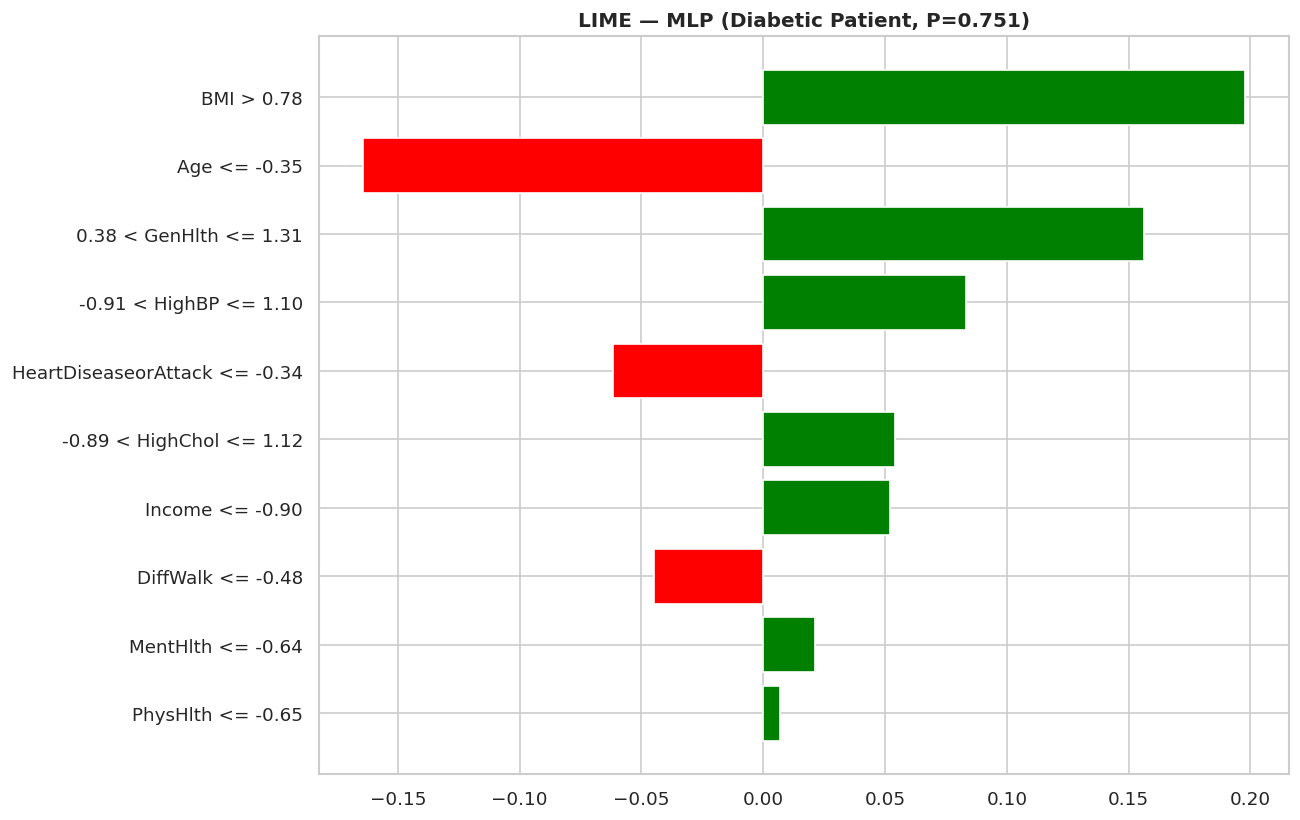

In [ ]:
lime_explainer_mlp = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_res,
    feature_names=FEATURES,
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification',
    random_state=RANDOM_STATE
)

# Wrapper: LIME expects predict_proba returning shape (n, 2)
def mlp_predict_proba(X):
    p1 = mlp_model.predict(X, verbose=0).flatten()
    return np.column_stack([1 - p1, p1])

pos_idx_m = np.where(y_test == 1)[0][0]
lime_exp_m = lime_explainer_mlp.explain_instance(
    data_row=X_test_scaled[pos_idx_m],
    predict_fn=mlp_predict_proba,
    num_features=10,
    num_samples=2000
)
prob_m = mlp_predict_proba(X_test_scaled[[pos_idx_m]])[0]
print(f"LIME MLP  P(No Diabetes)={prob_m[0]:.3f}  P(Diabetes)={prob_m[1]:.3f}")

fig = lime_exp_m.as_pyplot_figure(label=1)
fig.set_size_inches(11, 7)
plt.title(f'LIME — MLP (Diabetic Patient, P={prob_m[1]:.3f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_10_lime_single.png', bbox_inches='tight')
plt.show()

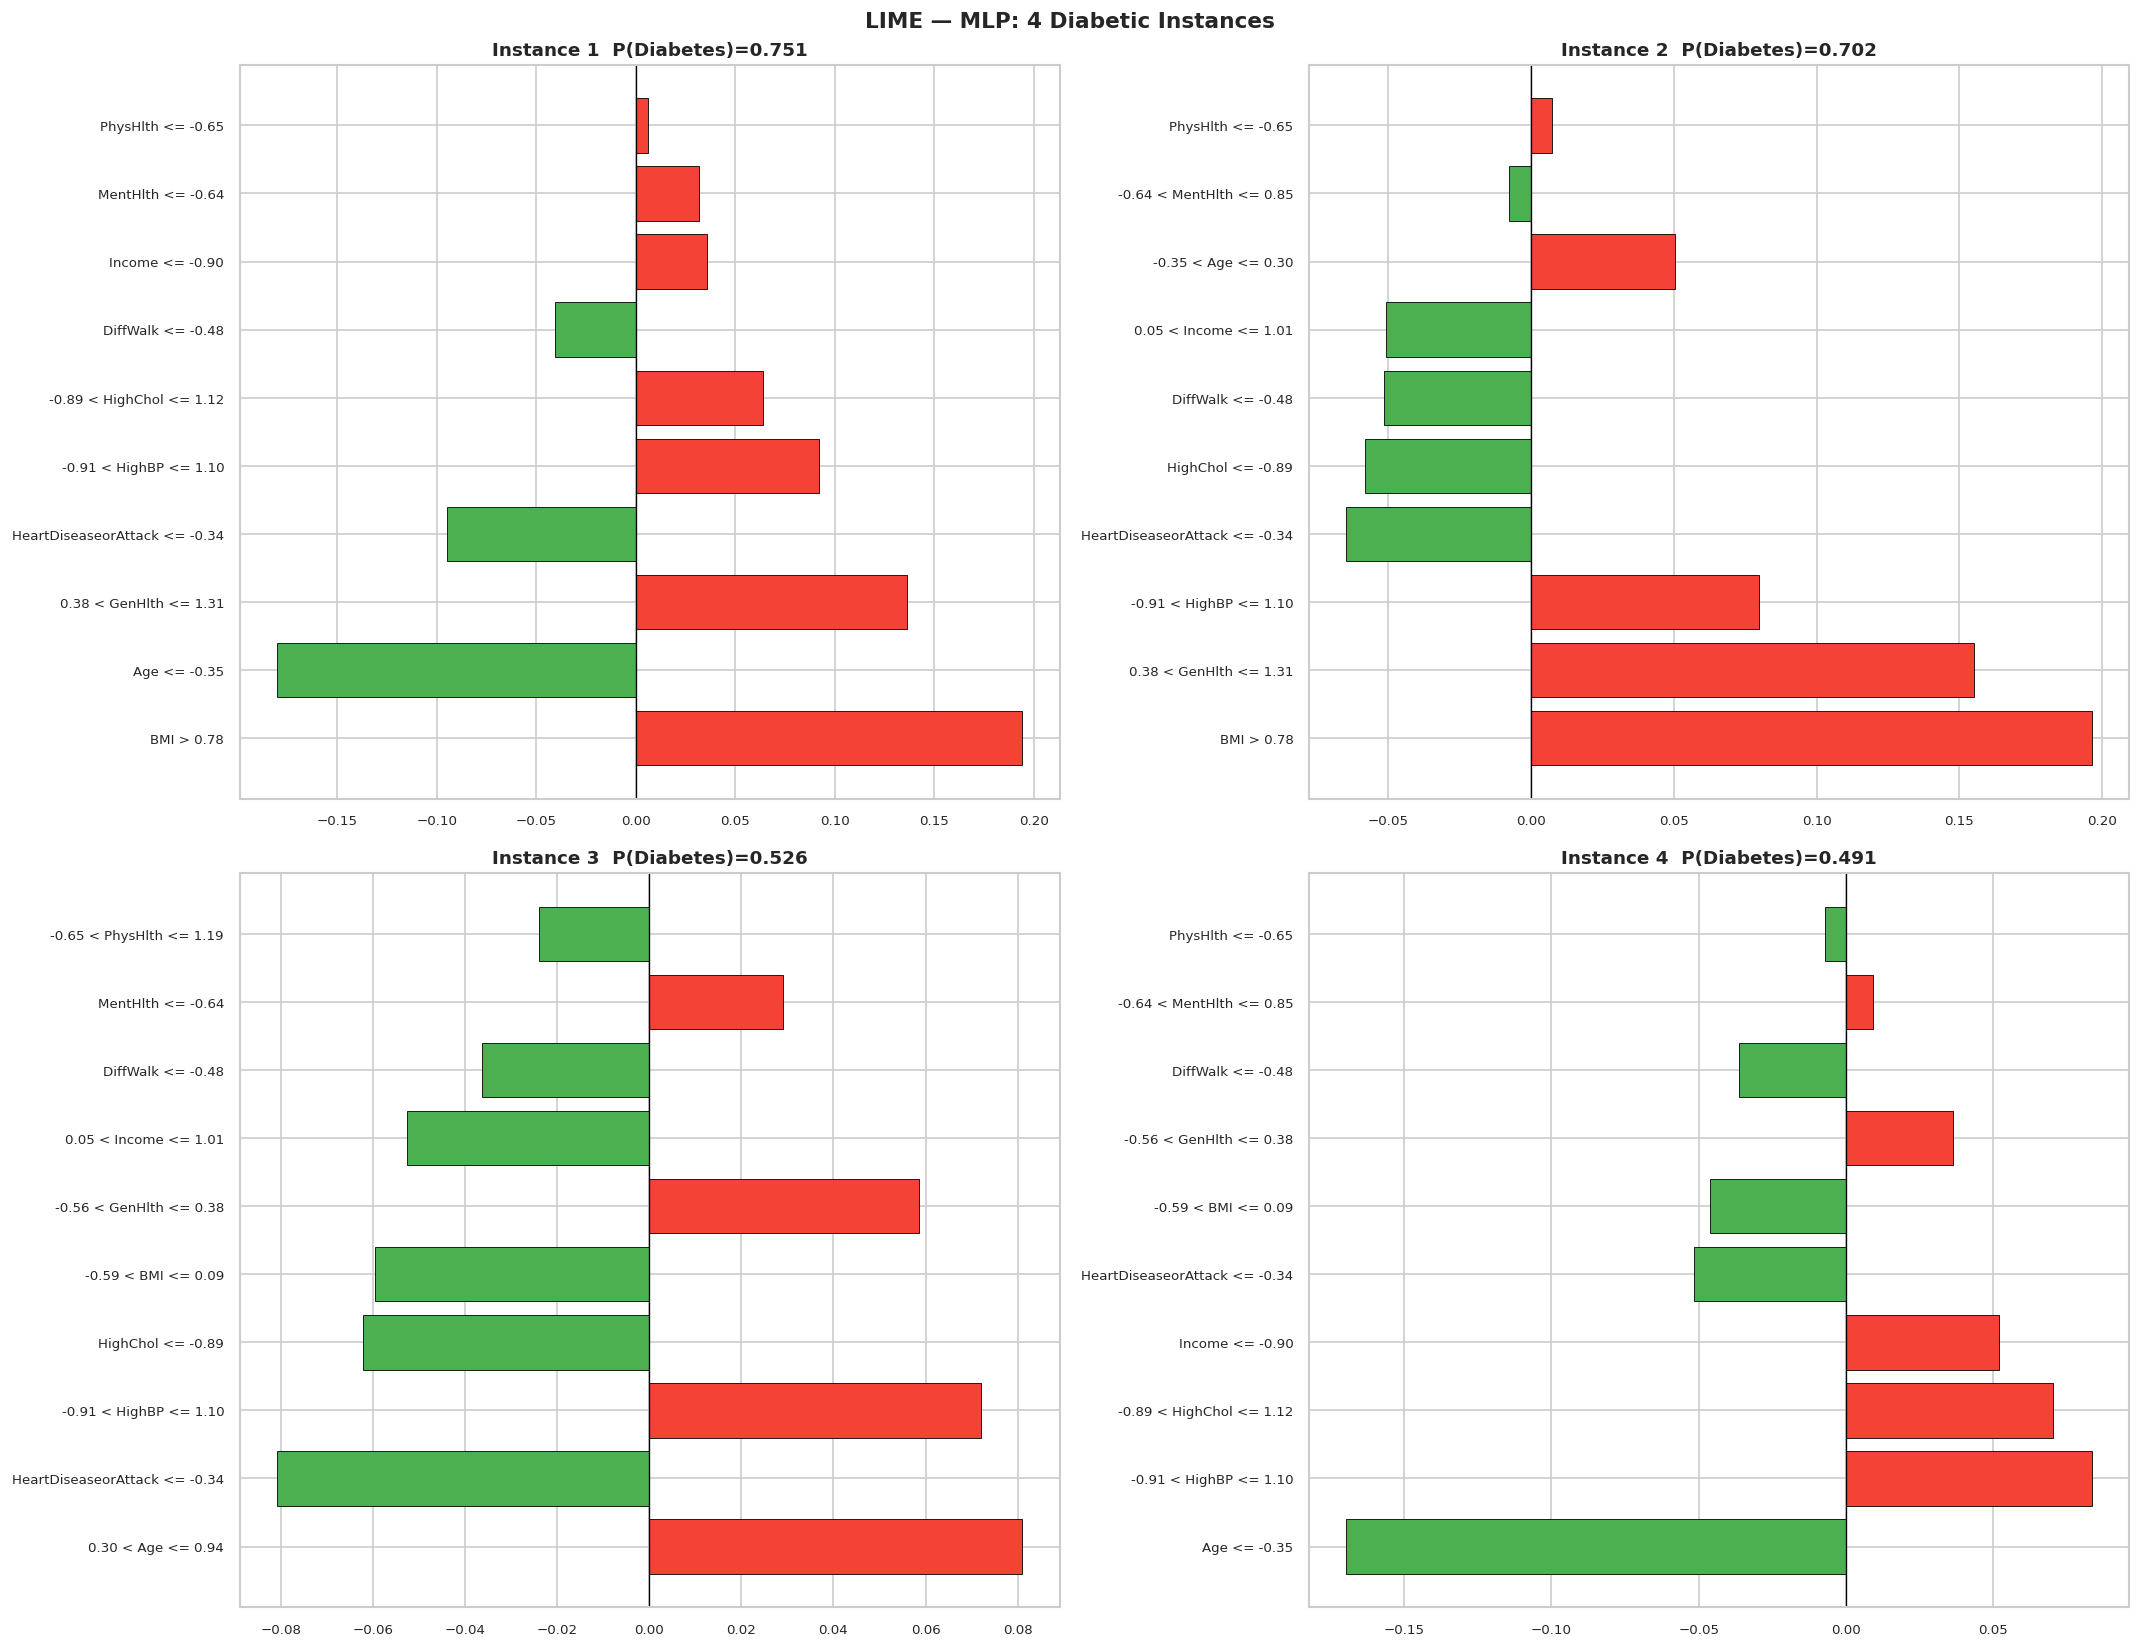

In [ ]:
# LIME for 4 diabetic instances
pos_indices_m = np.where(y_test == 1)[0][:4]
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
for i, idx in enumerate(pos_indices_m):
    inst = X_test_scaled[idx]
    exp = lime_explainer_mlp.explain_instance(
        data_row=inst, predict_fn=mlp_predict_proba,
        num_features=10, num_samples=1000
    )
    vals = exp.as_list(label=1)
    feats = [v[0] for v in vals]; weights = [v[1] for v in vals]
    colors = ['#F44336' if w > 0 else '#4CAF50' for w in weights]
    axes[i].barh(feats, weights, color=colors, edgecolor='black', linewidth=0.5)
    axes[i].axvline(0, color='black', linewidth=0.8)
    prob = mlp_predict_proba(X_test_scaled[[idx]])[0][1]
    axes[i].set_title(f'Instance {i+1}  P(Diabetes)={prob:.3f}', fontsize=11, fontweight='bold')
    axes[i].tick_params(labelsize=8)
plt.suptitle('LIME — MLP: 4 Diabetic Instances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_11_lime_multi.png', bbox_inches='tight')
plt.show()

### 6.3 Permutation Feature Importance

Computing permutation importance for MLP (10 repeats)...


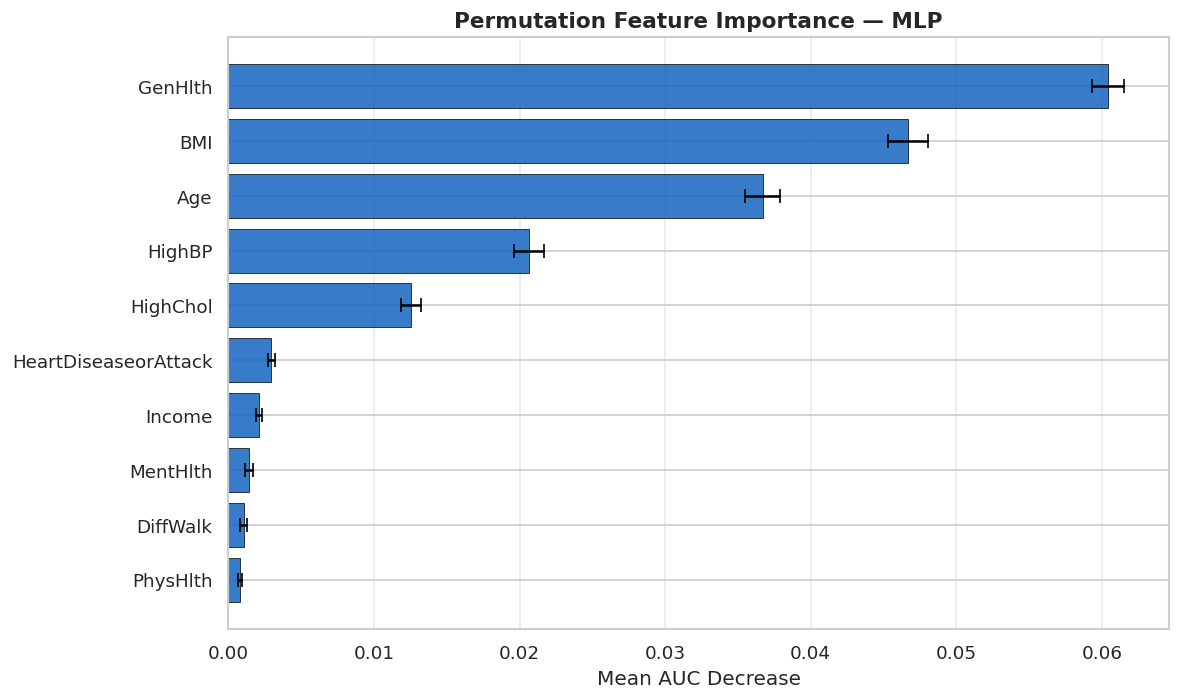

             Feature  Importance      Std
             GenHlth    0.060426 0.001100
                 BMI    0.046682 0.001356
                 Age    0.036699 0.001205
              HighBP    0.020647 0.001049
            HighChol    0.012548 0.000668
HeartDiseaseorAttack    0.002943 0.000238
              Income    0.002121 0.000206
            MentHlth    0.001411 0.000244
            DiffWalk    0.001040 0.000213
            PhysHlth    0.000785 0.000127


In [ ]:
print("Computing permutation importance for MLP (10 repeats)...")

from sklearn.metrics import roc_auc_score as _auc
from sklearn.base import BaseEstimator, ClassifierMixin

class KerasWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])
    def fit(self, X, y): return self
    def predict(self, X): return (self.model.predict(X, verbose=0).flatten() > 0.5).astype(int)
    def predict_proba(self, X):
        p1 = self.model.predict(X, verbose=0).flatten()
        return np.column_stack([1 - p1, p1])
    def score(self, X, y): return _auc(y, self.model.predict(X, verbose=0).flatten())

wrapped_mlp = KerasWrapper(mlp_model)

perm_mlp = permutation_importance(
    wrapped_mlp, X_test_scaled, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=1
)
pfi_mlp = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': perm_mlp.importances_mean,
    'Std'       : perm_mlp.importances_std
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(pfi_mlp['Feature'], pfi_mlp['Importance'],
         xerr=pfi_mlp['Std'], color='#1565C0', alpha=0.85,
         edgecolor='black', linewidth=0.5,
         error_kw={'elinewidth': 1.5, 'capsize': 4})
plt.xlabel('Mean AUC Decrease', fontsize=12)
plt.title('Permutation Feature Importance — MLP', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('mlp_12_permutation.png', bbox_inches='tight')
plt.show()
print(pfi_mlp.sort_values('Importance', ascending=False).to_string(index=False))


### 6.4 Partial Dependence Plots (PDP) + Individual Conditional Expectation (ICE)

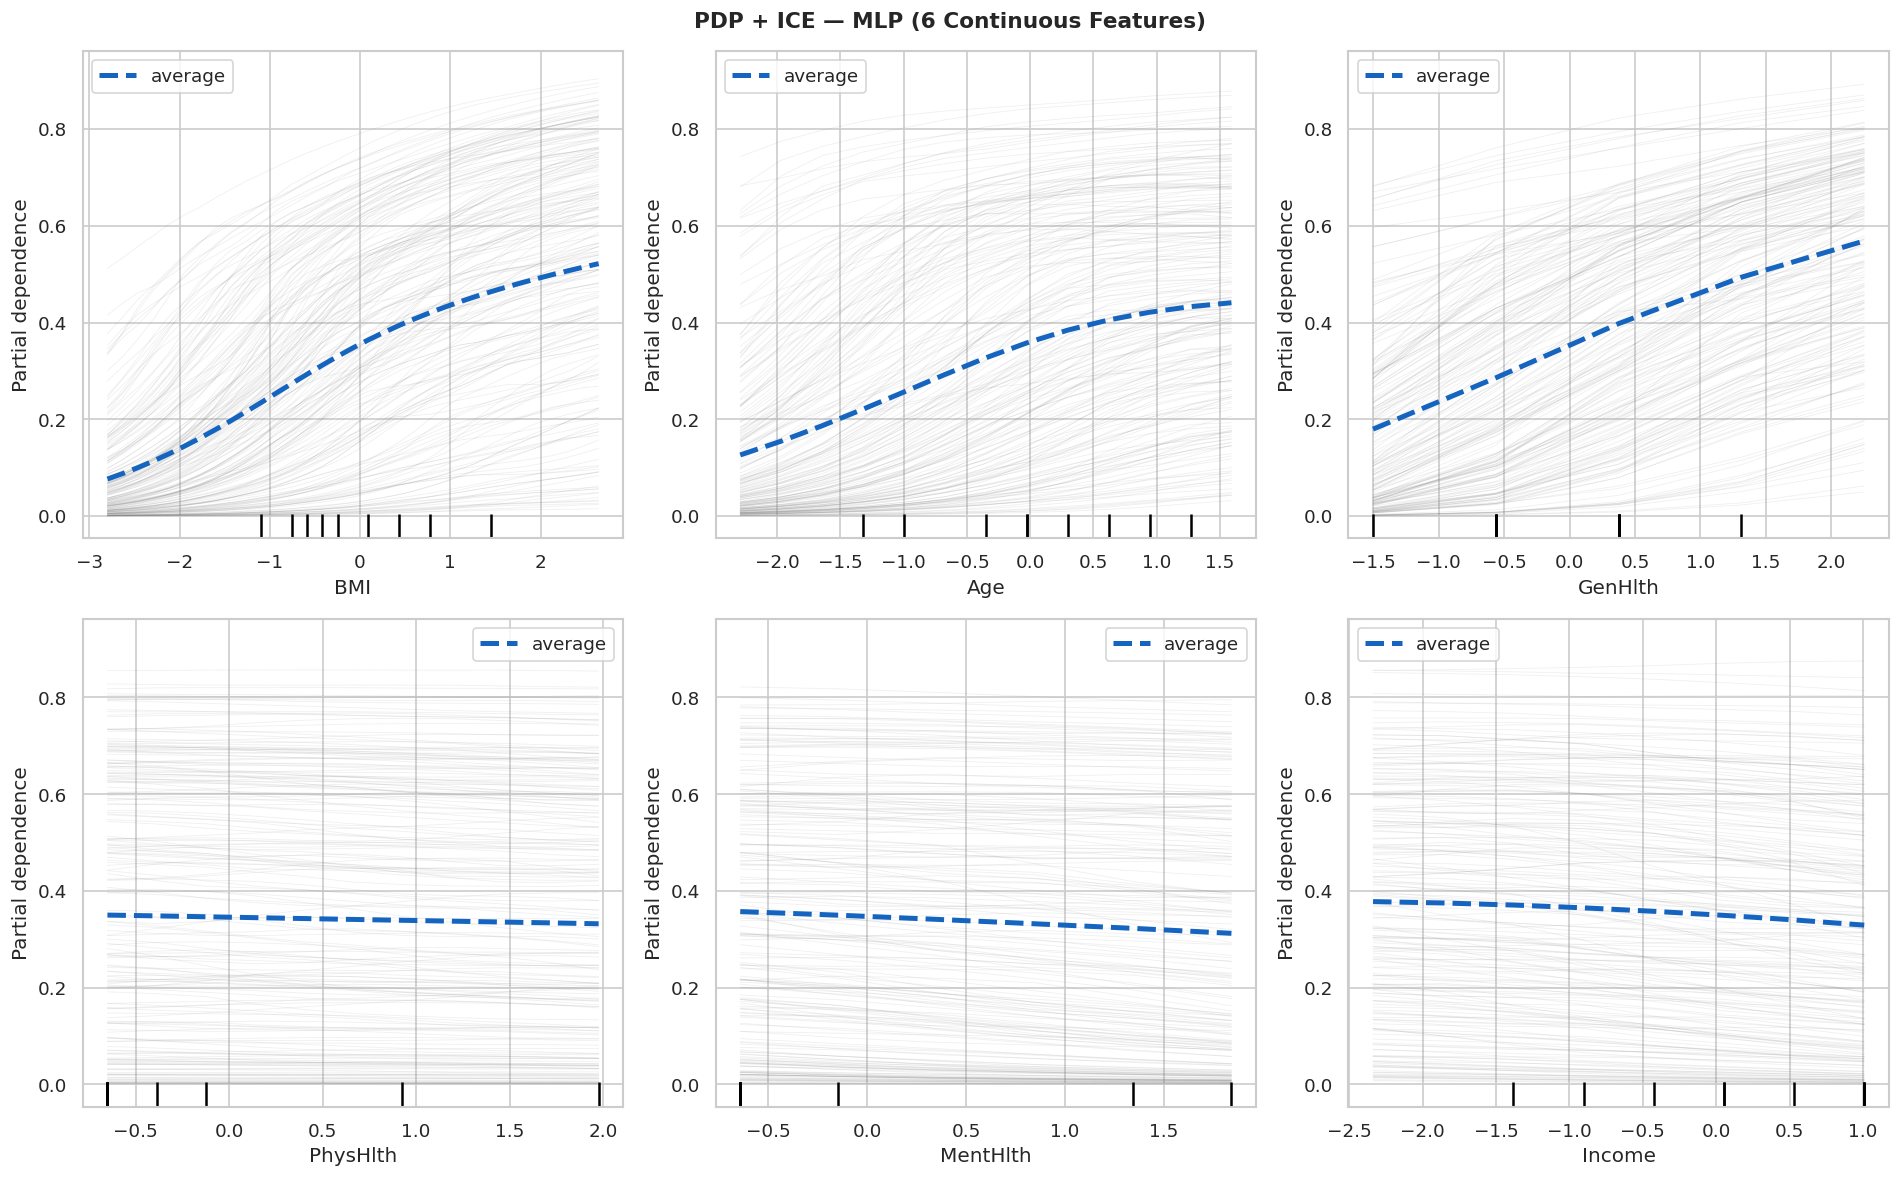

In [ ]:
from sklearn.metrics import roc_auc_score as _auc
from sklearn.base import BaseEstimator, ClassifierMixin

class KerasWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])
    def fit(self, X, y): return self
    def predict(self, X): return (self.model.predict(X, verbose=0).flatten() > 0.5).astype(int)
    def predict_proba(self, X):
        p1 = self.model.predict(X, verbose=0).flatten()
        return np.column_stack([1 - p1, p1])
    def score(self, X, y): return _auc(y, self.model.predict(X, verbose=0).flatten())

wrapped_mlp = KerasWrapper(mlp_model)

continuous_feats = ['BMI', 'Age', 'GenHlth', 'PhysHlth', 'MentHlth', 'Income']
feat_idx = [FEATURES.index(f) for f in continuous_feats]
X_test_df = pd.DataFrame(X_test_scaled, columns=FEATURES)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
PartialDependenceDisplay.from_estimator(
    wrapped_mlp, X_test_df.values,
    features=feat_idx, feature_names=FEATURES,
    kind='both', subsample=200, percentiles=(0.05, 0.95),
    grid_resolution=40, ax=axes.flatten(),
    ice_lines_kw={'color': 'grey', 'alpha': 0.12, 'linewidth': 0.5},
    pd_line_kw={'color': '#1565C0', 'linewidth': 3}
)
plt.suptitle('PDP + ICE — MLP (6 Continuous Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_13_pdp_ice.png', bbox_inches='tight')
plt.show()
